## Problem 1

An autoencoder consists of two parts:

- Encoder: compresses data into a latent representation
- Decoder: reconstructs the input

It is trained to reconstruct an original input with an objective of minimizing reconstruction error.

A GAN consistes of two competing networks:

- Generator: creates fake samples
- Discriminator: tries to distinguish real from fake

It is trained via a minimax game. 

| Feature       | Autoencoder                    | GAN                |
| ------------- | ------------------------------ | ------------------ |
| Training goal | Reconstruct input              | Fool discriminator |
| Loss type     | Reconstruction loss (MSE, BCE) | Adversarial loss   |
| Optimization  | Single objective               | Two-player game    |
| Stability     | Stable                         | Often unstable     |

Latent Space Behavior
Autoencoder

Latent space is learned implicitly

May not be smooth or well-structured

Standard AE cannot easily generate new realistic samples

Variational Autoencoder (VAE) fixes this via probabilistic modeling

GAN

Latent space is explicitly sampled (e.g., Gaussian noise)

Designed for generation

Often produces sharper, more realistic images

| Aspect                 | Autoencoder             | GAN                               |
| ---------------------- | ----------------------- | --------------------------------- |
| Reconstruction quality | Good for input recovery | Not focused on reconstruction     |
| Image sharpness        | Often blurry            | Usually sharp                     |
| Sample realism         | Moderate                | High (state-of-the-art in images) |


Typical Use Cases
Autoencoders

Dimensionality reduction (nonlinear PCA)

Denoising

Anomaly detection

Feature extraction

Pretraining

GANs

Image generation

Deepfake creation

Super-resolution

Style transfer

Data augmentation

## Problem 2

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 72
import numpy as np
import os
import sys

import torch
from torch import nn, optim
import torchvision
print(f'PyTorch version= {torch.__version__}')
print(f'torchvision version= {torchvision.__version__}')
print(f'CUDA available= {torch.cuda.is_available()}')

# Set the GPU to device 0
Device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

PyTorch version= 2.10.0
torchvision version= 0.25.0
CUDA available= True


The following code is modified to:
- Add a wgan_output path for comparison
- Use the smaller MNIST dataset

In [3]:
from torch.utils.data import DataLoader, ConcatDataset, Subset
import torchvision.datasets as dset
import torchvision.transforms as vtransforms
import torchvision.utils as vutils


# store images for debug  and info
DBG_FOLDER_GAN= 'output/gan_output'
DBG_FOLDER_WGAN= 'output/wgan_output'

IMG_SIZE= 28  # image size, square
BATCH_SIZE= 4096

# labels to learn
# FMNIST_LABELS = [1, 2, 3, 4, 5]
FMNIST_LABELS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


# concat both train and test
train_ds = dset.MNIST(root = "../../datasets", download=True, train=True,
                             transform=vtransforms.Compose([
                                 vtransforms.Resize([IMG_SIZE,IMG_SIZE], antialias=True),
                                 vtransforms.ToTensor(),
                                 vtransforms.Normalize((0.5,), (0.5,)) ]))
test_ds = dset.MNIST(root = "../../datasets", download=True, train=False,
                            transform=vtransforms.Compose([
                                vtransforms.Resize([IMG_SIZE,IMG_SIZE], antialias=True),
                                vtransforms.ToTensor(),
                                vtransforms.Normalize((0.5,), (0.5,)) ]))
ix1 = [_ for _, target in enumerate(train_ds.targets) if target in FMNIST_LABELS]
ix2 = [_ for _, target in enumerate(test_ds.targets) if target in FMNIST_LABELS]
gan_ds_ = ConcatDataset([Subset(train_ds,ix1),Subset(test_ds,ix2)])

Dloader_gan = DataLoader(gan_ds_, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=8, pin_memory=True, prefetch_factor=4, persistent_workers=True)

100%|██████████| 9.91M/9.91M [00:08<00:00, 1.17MB/s]
100%|██████████| 28.9k/28.9k [00:01<00:00, 28.3kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 776kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 43.0kB/s]


In [4]:
# Compute H, W for image size _H, _W
def findConv2dOutShape(_H, _W, _nn, pool=2):
    H = np.floor((_H+2*_nn.padding[0]-_nn.dilation[0]*(_nn.kernel_size[0]-1)-1)/_nn.stride[0]+1)
    W = np.floor((_W+2*_nn.padding[1]-_nn.dilation[1]*(_nn.kernel_size[1]-1)-1)/_nn.stride[1]+1)
    if pool:
        H, W = H/pool, W/pool
    return int(H), int(W)

def findConvTranspose2d(_H, _W, _nn, pool=2):
    H = (_H-1)*_nn.stride[0]-2*_nn.padding[0]+_nn.dilation[0]*(_nn.kernel_size[0]-1)+_nn.output_padding[0]+1
    W = (_W-1)*_nn.stride[1]-2*_nn.padding[1]+_nn.dilation[1]*(_nn.kernel_size[1]-1)+_nn.output_padding[1]+1
    if pool:
        H, W = H/pool, W/pool
    return int(H), int(W)

In [5]:
IMG_CHANNEL= 1
D_HIDDEN= 32

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

            nn.Conv2d(IMG_CHANNEL, D_HIDDEN, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2),

            nn.Conv2d(D_HIDDEN, 2*D_HIDDEN, 4, 2, 1, bias=False),
            nn.BatchNorm2d(2*D_HIDDEN),
            nn.LeakyReLU(0.2),

            nn.Conv2d(2*D_HIDDEN, 4*D_HIDDEN, 4, 2, 2, bias=False),
            nn.BatchNorm2d(4*D_HIDDEN),
            nn.LeakyReLU(0.2),

            nn.Conv2d(4*D_HIDDEN, 1, 4, 2, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, _input):
        return self.net(_input).view(-1, 1).squeeze(1)

# Check the network layers
print(Discriminator())

Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(2, 2), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(128, 1, kernel_size=(4, 4), stride=(2, 2), bias=False)
    (9): Sigmoid()
  )
)


We create the WGANDiscriminator which is the same as the GAN discriminator, but with the sigmoid removed. Removing the sigmoid changes the output from $(0,1)$ to $(-\infty,\infty)$ so, rather than a probability, we have any real number as an output which is necessary for a WGAN.

In [6]:
class WGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

            nn.Conv2d(IMG_CHANNEL, D_HIDDEN, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2),

            nn.Conv2d(D_HIDDEN, 2*D_HIDDEN, 4, 2, 1, bias=False),
            nn.BatchNorm2d(2*D_HIDDEN),
            nn.LeakyReLU(0.2),

            nn.Conv2d(2*D_HIDDEN, 4*D_HIDDEN, 4, 2, 2, bias=False),
            nn.BatchNorm2d(4*D_HIDDEN),
            nn.LeakyReLU(0.2),

            nn.Conv2d(4*D_HIDDEN, 1, 4, 2, 0, bias=False),
            # nn.Sigmoid() -- Remove the Sigmoid
        )
    def forward(self, _input):
        return self.net(_input).view(-1, 1).squeeze(1)

    # def forward(self, x):
    #     return self.net(x).view(-1)
    
# Check the network layers
print(WGANDiscriminator())

WGANDiscriminator(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(2, 2), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(128, 1, kernel_size=(4, 4), stride=(2, 2), bias=False)
  )
)


In [7]:
# Check the NN configuration
print(findConv2dOutShape(IMG_SIZE, IMG_SIZE, nn.Conv2d(IMG_CHANNEL, D_HIDDEN, 4, 2, 1), pool=0))
print(findConv2dOutShape(14, 14, nn.Conv2d(D_HIDDEN, 2*D_HIDDEN, 4, 2, 1), pool=0))
print(findConv2dOutShape(7, 7, nn.Conv2d(2*D_HIDDEN, 4*D_HIDDEN, 4, 2, 2), pool=0))
print(findConv2dOutShape(4, 4, nn.Conv2d(4*D_HIDDEN, 1, 4, 2, 0), pool=0))

(14, 14)
(7, 7)
(4, 4)
(1, 1)


In [8]:
G_HIDDEN= 32
Z_DIM= 128  # latent space dimension

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

            nn.ConvTranspose2d(Z_DIM, 4*G_HIDDEN, 4, 1, 0, bias=False),
            nn.BatchNorm2d(4*G_HIDDEN),
            nn.ReLU(),

            nn.ConvTranspose2d(4*G_HIDDEN, 2*G_HIDDEN, 4, 1, 0, bias=False),
            nn.BatchNorm2d(2*G_HIDDEN),
            nn.ReLU(),

            nn.ConvTranspose2d(2*G_HIDDEN, G_HIDDEN, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN),
            nn.ReLU(),

            nn.ConvTranspose2d(G_HIDDEN, IMG_CHANNEL, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, _input):
        return self.net(_input)

# Check the network layers
print(Generator())

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)


In [9]:
# Learning the real and fake - reminder this is not a classification problem
import os

class GAN():
    def __init__(self, epochs=20, eta=0.001, batch_size=1024, dbg_folder=DBG_FOLDER_GAN, info=False, savemodel=False):
        self.epochs, self.eta, self.B = epochs, eta, batch_size
        self.dbg_folder, self.info, self.savemodel = dbg_folder, info, savemodel
        self.criterion = nn.BCELoss()
        self.netD, self.netG, self.optimizerD, self.optimizerG = None, None, None, None
        self.LossDReal, self.LossDFake, self.LossG = None, None, None
        self.LabelReal = 1
        self.LabelFake = 0

    @classmethod
    # Initialize conv layers with N(0,0.02), batch norm layers N(1,0.02) and 0 bias
    def init_weights(cls, _m):
        if isinstance(_m, nn.Conv2d) or isinstance(_m, nn.ConvTranspose2d):
            torch.nn.init.normal_(_m.weight, mean=0.0, std=0.02)
        if isinstance(_m, nn.BatchNorm2d):
            torch.nn.init.normal_(_m.weight, mean=1.0, std=0.02)
            _m.bias.data.fill_(0.0)

    def initDG(self):
        self.netD = Discriminator().to(Device)
        self.netG = Generator().to(Device)
        # Optimizers
        self.optimizerD = optim.Adam(self.netD.parameters(), lr=self.eta, betas=(0.5, 0.999))
        self.optimizerG = optim.Adam(self.netG.parameters(), lr=self.eta, betas=(0.5, 0.999))
    
    def execD(self, _x_real, _real_label, _fake_label):
        self.netD.zero_grad()
        y_real = self.netD(_x_real)
        loss_D_real = self.criterion(y_real, _real_label)
        loss_D_real.backward()

        z_noise = torch.randn(_x_real.size(0), Z_DIM, 1, 1, device=Device)
        x_fake = self.netG(z_noise)
        y_fake = self.netD(x_fake.detach())
        loss_D_fake = self.criterion(y_fake, _fake_label)
        loss_D_fake.backward()
        self.optimizerD.step()
        return x_fake, loss_D_real, loss_D_fake
    
    def execG(self, _x_real, _real_label, _x_fake):
        self.netG.zero_grad()
        y_fake_r = self.netD(_x_fake)
        loss_G = self.criterion(y_fake_r, _real_label)
        loss_G.backward()
        self.optimizerG.step()
        return loss_G

    def fit(self, _train_dl):
        os.makedirs(self.dbg_folder, exist_ok=True)
        self.initDG()
        self.netD.apply(GAN.init_weights)
        self.netG.apply(GAN.init_weights)

        # Same noise sample to generate the sample fake
        viz_noise = torch.randn(self.B, Z_DIM, 1, 1, device=Device)

        self.LossDReal, self.LossDFake, self.LossG = [], [], []

        for e in range(self.epochs):
            lossDr, lossDf, lossG = [], [], []
            for i, data in enumerate(_train_dl):
                x_real = data[0].to(Device, non_blocking=True)
                real_label = torch.full((x_real.size(0),), self.LabelReal, dtype=torch.float32, device=Device)
                fake_label = torch.full((x_real.size(0),), self.LabelFake, dtype=torch.float32, device=Device)

                x_fake, loss_D_real, loss_D_fake = self.execD(x_real, real_label, fake_label)
                loss_G = self.execG(x_real, real_label, x_fake)

                if self.info:
                    sys.stderr.write("\r{:03d}/{:3d} | LossDr: {:6.3f} | lossDf: {:6.3f} | lossG: {:6.3f}".format(
                        e+1, self.epochs, loss_D_real.mean().item(), loss_D_fake.mean().item(), loss_G.mean().item()))
                    sys.stderr.flush()

                    if i == 0:
                        with torch.no_grad():
                            viz_sample = self.netG(viz_noise)
                            # output of the generator is Tanh()
                            vutils.save_image(vutils.make_grid(0.5-0.5*viz_sample[:32], nrow=4),
                                              f'{self.dbg_folder}/fake_samples_{e}.png', normalize=True)

                lossDr += [loss_D_real.mean().item()]  # check if the loss is shape 1 vector
                lossDf += [loss_D_fake.mean().item()]  # check if the loss is shape 1 vector
                lossG += [loss_G.mean().item()]  # check if the loss is shape 1 vector

            self.LossDReal += [(np.array(lossDr).mean(), np.array(lossDr).std())]
            self.LossDFake += [(np.array(lossDf).mean(), np.array(lossDf).std())]
            self.LossG += [(np.array(lossG).mean(), np.array(lossG).std())]
    
            if self.savemodel:
                torch.save(self.netG.state_dict(), f'{self.dbg_folder}/netG_{e}.pth')
                torch.save(self.netD.state_dict(), f'{self.dbg_folder}/netD_{e}.pth')

We create the WGAN class which:
- Use our WGANDiscriminator 
- Updates LabelReal and LabelFake to 1 and -1, respectively.
- Updates the loss function

In [10]:
class WGAN():
    def __init__(self, epochs=20, eta=0.001, batch_size=1024, dbg_folder=DBG_FOLDER_WGAN, info=False, savemodel=False, n_critic=5, clip_weight=0.01):
        self.epochs, self.eta, self.B = epochs, eta, batch_size
        self.dbg_folder, self.info, self.savemodel = dbg_folder, info, savemodel
        self.criterion = nn.BCELoss()
        self.netD, self.netG, self.optimizerD, self.optimizerG = None, None, None, None
        self.LossDReal, self.LossDFake, self.LossG = None, None, None
        self.LabelReal = +1
        self.LabelFake = -1
        self.n_critic = n_critic
        self.clip_weight = clip_weight

    @classmethod
    # Initialize conv layers with N(0,0.02), batch norm layers N(1,0.02) and 0 bias
    def init_weights(cls, _m):
        if isinstance(_m, nn.Conv2d) or isinstance(_m, nn.ConvTranspose2d):
            torch.nn.init.normal_(_m.weight, mean=0.0, std=0.02)
        if isinstance(_m, nn.BatchNorm2d):
            torch.nn.init.normal_(_m.weight, mean=1.0, std=0.02)
            _m.bias.data.fill_(0.0)

    def initDG(self):
        self.netD = WGANDiscriminator().to(Device)
        self.netG = Generator().to(Device)
        # Optimizers
        self.optimizerD = optim.RMSprop(self.netD.parameters(), lr=self.eta)
        self.optimizerG = optim.RMSprop(self.netG.parameters(), lr=self.eta)
    
    def execD(self, _x_real, _real_label, _fake_label):
        self.netD.zero_grad()
        y_real = self.netD(_x_real)

        z_noise = torch.randn(_x_real.size(0), Z_DIM, 1, 1, device=Device)
        x_fake = self.netG(z_noise)
        y_fake = self.netD(x_fake.detach())

        loss_D_real = -y_real.mean()
        loss_D_fake =  y_fake.mean()
        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        self.optimizerD.step()

        for p in self.netD.parameters():
            p.data.clamp_(-self.clip_weight, +self.clip_weight)

        return x_fake, loss_D_real, loss_D_fake
    
    def execG(self, _x_real, _real_label, _x_fake):
        self.netG.zero_grad()
        y_fake_r = self.netD(_x_fake)
        loss_G = -y_fake_r.mean()
        loss_G.backward()
        self.optimizerG.step()
        return loss_G

    def fit(self, _train_dl):
        os.makedirs(self.dbg_folder, exist_ok=True)
        self.initDG()
        self.netD.apply(GAN.init_weights)
        self.netG.apply(GAN.init_weights)

        # Same noise sample to generate the sample fake
        viz_noise = torch.randn(self.B, Z_DIM, 1, 1, device=Device)

        self.LossDReal, self.LossDFake, self.LossG = [], [], []

        for e in range(self.epochs):
            lossDr, lossDf, lossG = [], [], []
            for i, data in enumerate(_train_dl):
                x_real = data[0].to(Device, non_blocking=True)
                real_label = torch.full((x_real.size(0),), self.LabelReal, dtype=torch.float32, device=Device)
                fake_label = torch.full((x_real.size(0),), self.LabelFake, dtype=torch.float32, device=Device)

                for _ in range(self.n_critic):
                    x_fake, loss_D_real, loss_D_fake = self.execD(x_real, real_label, fake_label)

                loss_G = self.execG(x_real, real_label, x_fake)

                if self.info:
                    sys.stderr.write("\r{:03d}/{:3d} | LossDr: {:6.3f} | lossDf: {:6.3f} | lossG: {:6.3f}".format(
                        e+1, self.epochs, loss_D_real.mean().item(), loss_D_fake.mean().item(), loss_G.mean().item()))
                    sys.stderr.flush()

                    if i == 0:
                        with torch.no_grad():
                            viz_sample = self.netG(viz_noise)
                            # output of the generator is Tanh()
                            vutils.save_image(vutils.make_grid(0.5-0.5*viz_sample[:32], nrow=4),
                                              f'{self.dbg_folder}/wgan_fake_samples_{e}.png', normalize=True)

                lossDr += [loss_D_real.mean().item()]  # check if the loss is shape 1 vector
                lossDf += [loss_D_fake.mean().item()]  # check if the loss is shape 1 vector
                lossG += [loss_G.mean().item()]  # check if the loss is shape 1 vector

            self.LossDReal += [(np.array(lossDr).mean(), np.array(lossDr).std())]
            self.LossDFake += [(np.array(lossDf).mean(), np.array(lossDf).std())]
            self.LossG += [(np.array(lossG).mean(), np.array(lossG).std())]
    
            if self.savemodel:
                torch.save(self.netG.state_dict(), f'{self.dbg_folder}/wgan_netG_{e}.pth')
                torch.save(self.netD.state_dict(), f'{self.dbg_folder}/wgan_netD_{e}.pth')


In [13]:
EPOCHS = 90
BATCH_SIZE = 1024

In [14]:
%%time



wgan = WGAN(epochs=EPOCHS, eta=5e-5, batch_size=BATCH_SIZE, info=True, savemodel=True, n_critic=5, clip_weight=0.01)
wgan.fit(Dloader_gan)

090/ 90 | LossDr: -0.003 | lossDf: -0.044 | lossG:  0.005

CPU times: total: 1h 50min 18s
Wall time: 1h 51min 10s


In [16]:
%%time



wgan = WGAN(epochs=EPOCHS, eta=5e-5, batch_size=BATCH_SIZE, info=True, savemodel=True, n_critic=5, clip_weight=0.05)
wgan.fit(Dloader_gan)

090/ 90 | LossDr: -2.753 | lossDf: -1.223 | lossG:  3.254

CPU times: total: 1h 50min 36s
Wall time: 1h 51min 25s


In [15]:
%%time

gan = GAN(epochs=EPOCHS, eta=0.001, batch_size=BATCH_SIZE, info=True, savemodel=True)
gan.fit(Dloader_gan)

090/ 90 | LossDr:  0.755 | lossDf:  0.279 | lossG:  0.740

CPU times: total: 9min 39s
Wall time: 10min 23s


In [18]:
# Draw stored fake epochs
def draw_strip(_folder, _rowlist, _collist):
    assert len(_rowlist)==5 and len(_collist)==5
    # epoch
    ix =  np.linspace(1, EPOCHS-1, num=10, dtype=int)
    # position excluding the grid
    def img_xy(x, y):
        return 2*(x+1)+IMG_SIZE*x, 2*(y+1)+IMG_SIZE*y
    plt.figure(1, figsize=(12, 8), dpi=72)
    for offs, (i1,j1) in enumerate(zip(_rowlist,_collist)):
        x, y = img_xy(i1,j1)
        for i, e in enumerate(ix):
            img = plt.imread(f'{_folder}/fake_samples_{e}.png')
            plt.subplot(5, 10, 10*offs + i+1)
            plt.axis('off')
            plt.imshow(img[x:x+IMG_SIZE,y:y+IMG_SIZE], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.show()

In [19]:
def draw_generated(_netG):
    plt.figure(1, figsize=(10, 5), dpi=72)
    for i in range(7):
        plt.subplot(1, 7, i+1)
        with torch.no_grad():
            x_fake = _netG(torch.randn(1, Z_DIM, 1, 1, device=Device))
        plt.axis('off')
        plt.imshow(x_fake.to('cpu').numpy().reshape(IMG_SIZE,IMG_SIZE), cmap=plt.cm.gray_r, interpolation='nearest')
    plt.show()

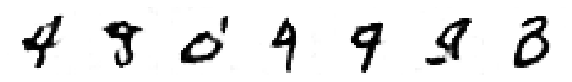

In [20]:
# Load saved weights during training, generate a fake image
netG2 = Generator()
netG2.load_state_dict(torch.load(f'{DBG_FOLDER_GAN}/netG_{EPOCHS-1:d}.pth', weights_only=True))
netG2.to(Device)

draw_generated(netG2)

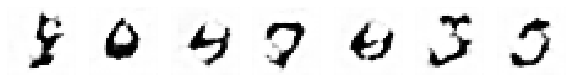

In [26]:
# Load saved weights during training, generate a fake image
netG2 = Generator()
netG2.load_state_dict(torch.load(f'{DBG_FOLDER_WGAN}_clip_weight_001/wgan_netG_{EPOCHS-1:d}.pth', weights_only=True))
netG2.to(Device)

draw_generated(netG2)

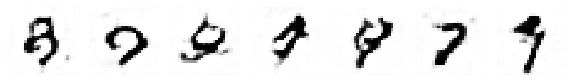

In [27]:
# Load saved weights during training, generate a fake image
netG2 = Generator()
netG2.load_state_dict(torch.load(f'{DBG_FOLDER_WGAN}_clip_weight_005/wgan_netG_{EPOCHS-1:d}.pth', weights_only=True))
netG2.to(Device)

draw_generated(netG2)

In [22]:
def plot_error(_lsDreal, _lsDfake, _lsG):
    # plot the error, skip first error due to large difference, initial condition
    plt.figure(figsize=(8, 6))
    x = [_ for _ in range(len(_lsDreal[1:]))]
    y1_dr, y2_dr = np.array([_[0] for _ in _lsDreal[1:]]), np.array([_[1] for _ in _lsDreal[1:]])
    y1_df, y2_df = np.array([_[0] for _ in _lsDfake[1:]]), np.array([_[1] for _ in _lsDfake[1:]])
    y1_g, y2_g = np.array([_[0] for _ in _lsG[1:]]), np.array([_[1] for _ in _lsG[1:]])
    plt.plot(y1_dr, label='Dis Real', c='darkorchid')
    plt.fill_between(x, y1_dr-y2_dr, y1_dr+y2_dr, color='darkorchid', alpha=0.1)
    plt.plot(y1_df, label='Dis Fake', c='deepskyblue')
    plt.fill_between(x, y1_df-y2_df, y1_df+y2_df, color='deepskyblue', alpha=0.1)
    plt.plot(y1_g, label='Gen', c='coral')
    plt.fill_between(x, y1_g-y2_g, y1_g+y2_g, color='coral', alpha=0.1)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(axis='y')
    plt.legend()
    plt.show()

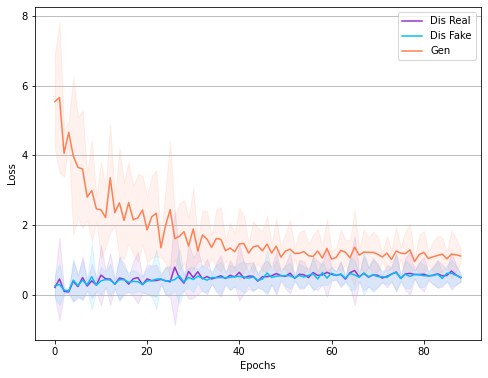

In [23]:
plot_error(gan.LossDReal, gan.LossDFake, gan.LossG)

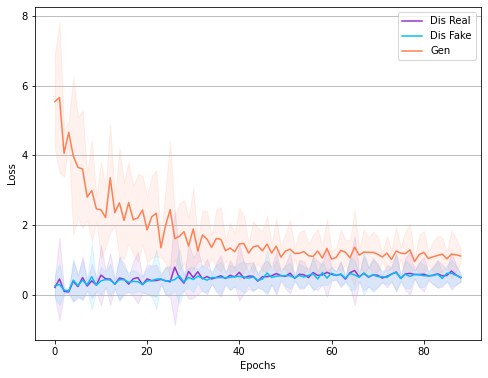

AttributeError: 'WGAN' object has no attribute 'LossD'

In [25]:
def plot_wgan(lossD, lossG):
    yD = np.array([t[0] for t in lossD])
    yG = np.array([t[0] for t in lossG])
    plt.plot(yD, label="WGAN Critic Loss")
    plt.plot(yG, label="WGAN Generator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_error(gan.LossDReal, gan.LossDFake, gan.LossG)
plot_wgan(wgan.LossD, wgan.LossG)